## Bibliothèques

#### librairie "morta_nuts2" construite

In [1]:
1

1

In [2]:
import sys, os
sys.path.append(os.path.abspath(".."))
import geopandas as gpd
import sys
sys.executable
import numpy as np

In [3]:
from morta_nuts2.data.eurostat import*
from morta_nuts2.data.mortality_table import*
from morta_nuts2.model.Bsplines.Bsplines import make_bspline_basis
from morta_nuts2.model.parameters_init.param_init import*
from morta_nuts2.model.projection.project_class import*
from morta_nuts2.model.LC_p.lcp_class import*
from morta_nuts2.model.LL_p.llp_class import*
from morta_nuts2.graph.plot_class import*

### Test fonctions imports de data eurostat

In [4]:

#EurostatConfig.set_default_shapefile("D:/mes_donnees/NUTS_2024.shp") # implémenter par defaut mais possible de le changer
EurostatConfig.set_default_data_path("C:/Users/Idrissa Belem/Documents/GitHub/morta_nuts2/data")

data_brute = Eurostat_data()

#Chargement des données - ultra simple
mortality_fr = data_brute.load("mortality", "BE")
deaths_fr = data_brute.load("deaths", "BE")
population_fr = data_brute.load("population", "BE")


#Tout charger d'un coup en dictionnaire
#data_fr = data_brute.load_all("FR")




📂 Loading NUTS shapefile... NUTS_RG_01M_2024_3035.shp
✅ Shapefile loaded (1798 features)
💾 [Eurostat] Cache → BE_mxt_raw.csv
💾 [Eurostat] Cache → BE_Dxt_raw.csv
💾 [Eurostat] Cache → BE_Lxt_raw.csv


### Test function for data create

In [5]:
morta = MortalityCalculator()
table = morta.calculate_mortality(mortality_fr,population_fr,deaths_fr,gender="T")

2026-03-24 10:24:03,640 - MortalityCalculator - INFO - Loading shapefile: c:\Users\Idrissa Belem\Documents\GitHub\morta_nuts2\NUTS_files\NUTS_RG_01M_2024_3035.shp
2026-03-24 10:24:03,940 - MortalityCalculator - INFO - 1793 regions loaded
2026-03-24 10:24:03,955 - MortalityCalculator - INFO - MortalityCalculator initialized with 1793 regions
2026-03-24 10:24:03,957 - MortalityCalculator - INFO - Validating input data...
2026-03-24 10:24:05,477 - MortalityCalculator - INFO - Validation successful
2026-03-24 10:24:05,478 - root - INFO - validate_input_data executed in 1.52 seconds
2026-03-24 10:24:05,512 - MortalityCalculator - INFO - Result retrieved from cache
2026-03-24 10:24:05,514 - root - INFO - calculate_mortality executed in 1.56 seconds


In [6]:
table = table[table['year'] != 2024]

#### Paramètres

In [7]:
Muxtg,Dxtg, Extg, xv, tv, regions = build_input_from_dataframe(table)

print("Shape Dxtg :", Dxtg.shape)
print("Shape Extg :", Extg.shape)
print("Shape Muxtg :", Muxtg.shape)
print("Ages :", len(xv))
print("Years :", len(tv))
print("Regions :", len(regions))
nb_regions = len(regions)
nb_years = len(tv)
degree = 3
n_knots = 25
nb_iter = 5000
lam = 0
Dxt = np.sum(Dxtg, axis=2)
Ext = np.sum(Extg, axis=2)
path_fr ="C:/Users/Idrissa Belem/Documents/GitHub/morta_nuts2/output_note/BE"


Shape Dxtg : (83, 34, 11)
Shape Extg : (83, 34, 11)
Shape Muxtg : (83, 34, 11)
Ages : 83
Years : 34
Regions : 11


#### modèle Lee carter 

###### modèle Lee carter non paramétrique

In [8]:
#LC initial values
ax_init   = -0.001*np.zeros_like(xv)
bx_init   = 0.001*np.ones_like(xv)
kappa_init= np.ones(len(tv))


In [9]:
model_classic = LeeCarter.Classic(nb_iter=nb_iter, eta=1)

results_lc_classic = model_classic.fit(
    ax     = ax_init,
    bx     = bx_init,
    kappa  = kappa_init,
    Extg   = Extg,
    Dxtg   = Dxtg,
    xv     = xv,
    tv     = tv,
)

In [10]:
results_lc_classic['fit_statistics']

,N,m,degree,dofs,lnL,AIC,BIC
0,31042,NA,NA,200,-109700.37,219800.73,221469.35


###### modèle Lee carter paramétrique

In [11]:
_, _, n_basis = make_bspline_basis(
    xv, degree, n_knots)

In [12]:
ax_coef_init, bx_coef_init, kappa_init = lcp_parametrique_init_national(
    Dxtg, Extg, xv, tv, n_basis=n_basis, degree=degree, n_knots=n_knots
)


In [13]:
# 
model_nat = LeeCarter.Parametric.National(
    degree=degree,
    n_knots=n_knots,
    lam=lam,
    nb_iter=nb_iter,
    eta0=0.2,
    tol=1e-4,
    verbose=True,
)

results_lcp_nat = model_nat.fit(
    ax_coef_init  = ax_coef_init,
    bx_coef_init  = bx_coef_init,
    kappa_init    = kappa_init,
    Extg          = Extg,
    Dxtg          = Dxtg,
    xv            = xv,
    tv            = tv,)

It    0 | lnL = -110568.3207 | Δ = +inf | η = 0.20000
It   10 | lnL = -109836.4380 | Δ = +2.495263 | η = 0.32578
It   20 | lnL = -109831.7263 | Δ = +0.167556 | η = 0.53066
It   30 | lnL = -109830.8684 | Δ = +0.039779 | η = 0.86439
It   40 | lnL = -109830.7007 | Δ = +0.005724 | η = 1.40800
It   50 | lnL = -109830.6865 | Δ = -0.003114 | η = 2.00000

Convergence reached (tolerance) at it 51.

FINAL STATISTICS
    N  n_basis  dofs        lnL     deviance       AIC       BIC
31042       27  88.0 -109830.68 -21573927.89 219837.37 220571.56


#### Modèle Lee and Li

###### modèle Lee and Li non paramétrique

In [14]:
#------------------------------------------------------------------------------
bx_gr_init    =   0.0000010*np.ones((len(xv),len(regions)))
kappa_gr_init =   0.0000010*np.ones((len(tv),len(regions)))


In [15]:
model_c = LiLee.Classic(nb_iter=nb_iter,
                         verbose=False)

result_ll = model_c.fit(
    ax       = ax_init,
    bx       = bx_init,
    bx_gr    = bx_gr_init,
    kappa    = kappa_init,
    kappa_gr = kappa_gr_init,
    Extg     = Extg,
    Dxtg     = Dxtg,
    Muxtg    = Muxtg,
    xv       = xv,
    tv       = tv,
)

###### modèle Lee and Li avec Bsplines paramétrique

In [16]:
model_p = LiLee.Parametric.FullModel(
    degree=degree,
    n_knots=n_knots,
    lam=lam,
    nb_iter=10000,
    eta0=0.2,
    tol=1e-3,
    verbose=True,
)


init = model_p.init_params(Dxtg, Extg, xv)

In [17]:
result_llp = model_p.fit(*init, Extg, Dxtg, xv, tv)

PARAMETRIC LI-LEE MODEL CALIBRATION
Parameters: degree=3, n_knots=25, lam=0
Data: 83 ages × 34 years × 11 regions
Number of basis functions: 27
It    0 | lnL = -134,275.77 | Δ = -134275.769293 | η = 0.10000
It   10 | lnL = -91,276.36 | Δ = +256.889337 | η = 0.07757
It   20 | lnL = -90,148.90 | Δ = +63.195585 | η = 0.12635
It   30 | lnL = -89,757.06 | Δ = +25.045371 | η = 0.20581
It   40 | lnL = -89,580.10 | Δ = +14.076704 | η = 0.33524
It   50 | lnL = -89,447.35 | Δ = +14.018290 | η = 0.54607
It   60 | lnL = -89,282.36 | Δ = +16.776154 | η = 0.88949
It   70 | lnL = -89,133.38 | Δ = +12.324796 | η = 1.44888
It   80 | lnL = -89,343.47 | Δ = +352.996504 | η = 0.12135
It   90 | lnL = -89,084.25 | Δ = +4.976464 | η = 0.19767
It  100 | lnL = -89,041.32 | Δ = +4.427163 | η = 0.32198
It  110 | lnL = -88,992.84 | Δ = +5.104575 | η = 0.52448
It  120 | lnL = -88,942.22 | Δ = +4.861806 | η = 0.85432
It  130 | lnL = -88,900.02 | Δ = +3.586221 | η = 1.39159
It  140 | lnL = -90,114.75 | Δ = +1867.403

In [18]:
# kappa_g = result_llp['parameters']["kappa_g"]
# mask    = ~np.isin(tv, [2020, 2021])

# print("Drift kappa_g par région après fit :")
# for g, name in enumerate(regions):
#     drift = np.diff(kappa_g[ g,mask]).mean()
#     sens  = "↓ OK" if drift < 0 else "↑ PROBLÈME"
#     print(f"  {name}: {drift:.4f}  {sens}")

In [20]:
import pandas as pd

models = {
    "LC": results_lc_classic,
    "LC parametric": results_lcp_nat,
    "Li-Lee": result_ll,
    "Li-Lee parametric": result_llp,
}

rows = []

for name, result in models.items():
    stats = result['fit_statistics'].iloc[0]
    
    rows.append({
        "Model": name,
        "N": stats["N"],
        "dofs": stats["dofs"],
        "lnL": stats["lnL"],
        "AIC": stats["AIC"],
        "BIC": stats["BIC"]
    })

comparison_table = pd.DataFrame(rows)


#comparison_table.to_csv(path_fr + "/models.csv", index=False)

##### MAE & WMAE

In [21]:
mae_ll = compute_mae(Muxtg, result_ll['fitted_values']['mu'], weights=Extg)
mae_llp = compute_mae(Muxtg, result_llp['fitted_values']['mu'], weights=Extg)
mae_lcp = compute_mae(Muxtg, results_lcp_nat['fitted_values']['mu'], weights=Extg)

print(f"MAE  global — LC : {mae_ll['global']:.6f} | LL : {mae_llp['global']:.6f}")
print(f"WMAE global — LC : {mae_ll['wmae_global']:.6f} | LL : {mae_llp['wmae_global']:.6f}")

MAE  global — LC : 0.000707 | LL : 0.000671
WMAE global — LC : 0.000472 | LL : 0.000445


C:\Users\Idrissa Belem\Documents\GitHub\morta_nuts2\src\morta_nuts2\graph\plot_class.py:698: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


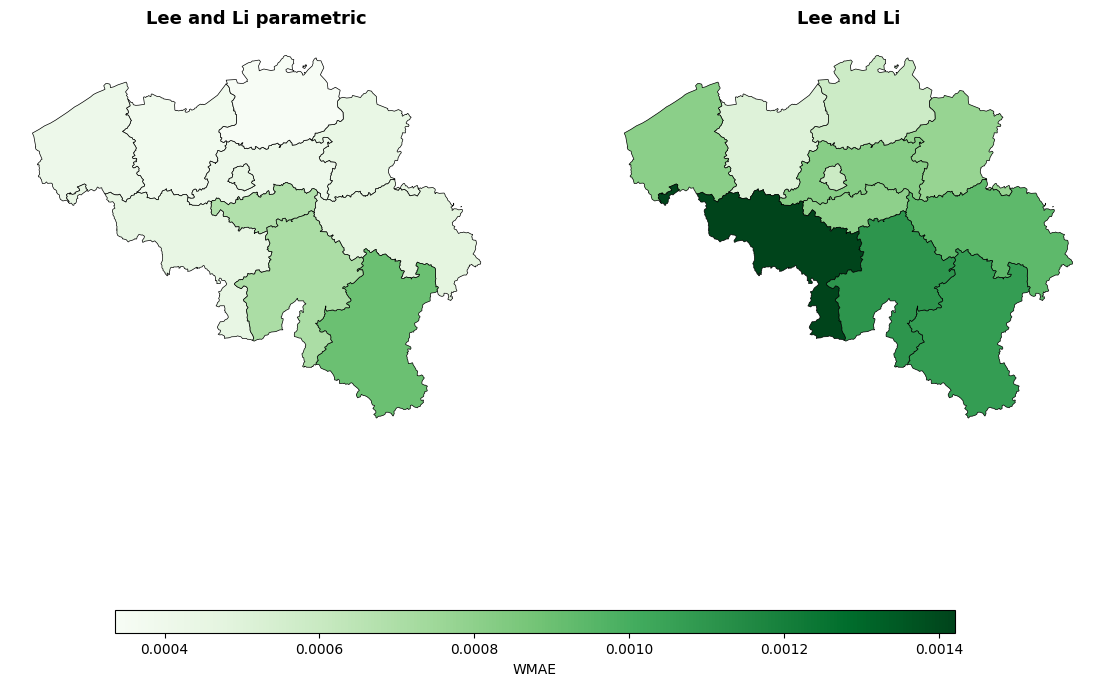

✅ Saved → C:/Users/Idrissa Belem/Documents/GitHub/morta_nuts2/output_note/BE/WMAE_llp_vs_lc_color_Detra.png


In [22]:
tv_future = np.arange(1990, 2024) #années
mp = MapPlotter(regions, mae_llp['wmae_by_region'], tv_future, "BE", "WMAE")
#mp.plot_static(mae_llp['wmae_by_region'])
mp.plot_compare_models(
    other_data=mae_lcp['wmae_by_region'],
    model_labels=("Lee and Li parametric", "Lee and Li"),
    static=True,
    cmap_diverging="Greens",   # diverging pour erreurs signées
)
mp.save(path_fr +"/WMAE_llp_vs_lc_color_Detra.png")

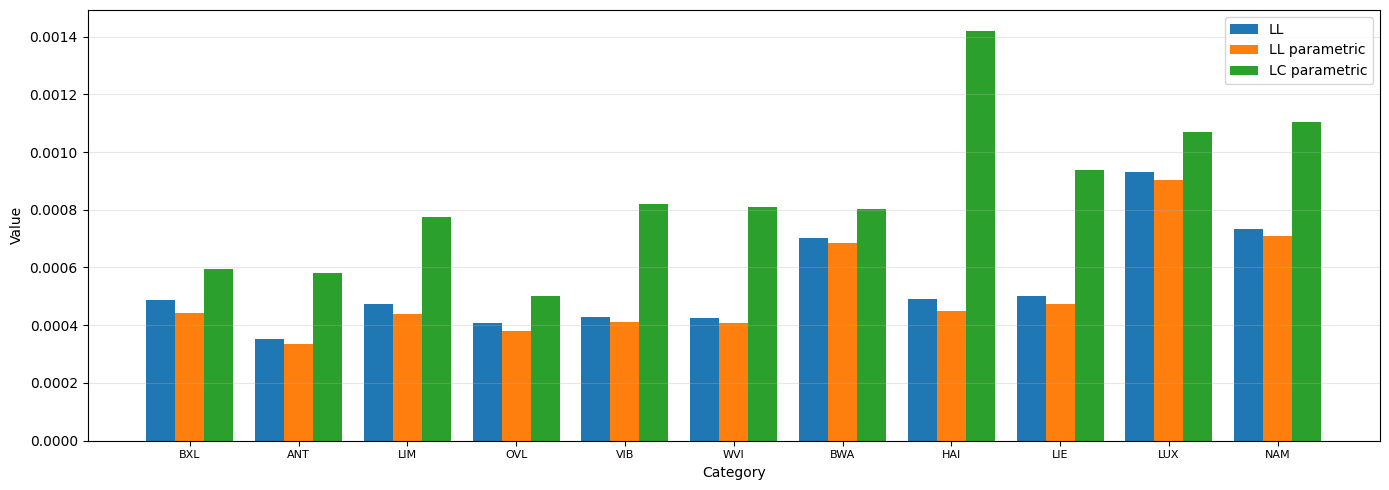

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# --- Tes arrays de MAE par modèle ---
mae = {
    "LL":  mae_ll['wmae_by_region'] ,  # ton array
    "LL parametric":      mae_llp['wmae_by_region'],
     "LC parametric": mae_lcp["wmae_by_region"] }
    
#-------- abbreviation of NUTS 2 regions --------
Bel_nuts2 = {
    "BE10": "BXL",
    "BE21": "ANT",
    "BE22": "LIM",
    "BE23": "OVL",
    "BE24": "VlB",
    "BE25": "WVl",
    "BE31": "BWA",
    "BE32": "HAI",
    "BE33": "LIE",
    "BE34": "LUX",
    "BE35": "NAM"
}


# France_nuts2 = {
#     "FR10": "IDF", "FRB0": "CVL", "FRC1": "BOU", "FRC2": "FCO",
#     "FRD1": "BN",  "FRD2": "HN",  "FRE1": "NPC", "FRE2": "PIC",
#     "FRF1": "ALS", "FRF2": "CHA", "FRF3": "LOR", "FRG0": "PDL",
#     "FRH0": "BRE", "FRI1": "AQU", "FRI2": "LIM", "FRI3": "POI",
#     "FRJ1": "LR",  "FRJ2": "MPY", "FRK1": "AUV", "FRK2": "RA",
#     "FRL0": "PACA","FRM0": "COR"
# }
region_labels = list(Bel_nuts2.values())

models  = list(mae.keys())
colors  = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]  # bleu, orange, vert, rouge
n       = len(region_labels)
n_models = len(models)
width   = 0.8 / n_models  # barres qui se touchent presque
x       = np.arange(n)

fig, ax = plt.subplots(figsize=(14, 5))

for i, (model, color) in enumerate(zip(models, colors)):
    offset = (i - n_models / 2 + 0.5) * width
    ax.bar(x + offset, mae[model], width, label=model, color=color)

ax.set_xticks(x)
ax.set_xticklabels(region_labels, rotation=0, fontsize=8)
ax.set_xlabel("Category")
ax.set_ylabel("Value")
ax.legend()
ax.grid(axis="y", alpha=0.3)
#ax.set_title("Histogram of weighted mean absolute errors by regions, France.")
#plt.savefig(path_fr + "/Histogram_wmae.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [24]:
import pandas as pd

# DataFrame avec régions en index
df_wmae = pd.DataFrame(mae, index=region_labels)

# Affichage
df_wmae

,LL,LL parametric,LC parametric
BXL,0.000488,0.000441,0.000594
ANT,0.000351,0.000336,0.000582
LIM,0.000475,0.000439,0.000773
OVL,0.000407,0.000381,0.000501
VlB,0.000430,0.000410,0.000819
WVl,0.000424,0.000408,0.000810
BWA,0.000704,0.000686,0.000801
HAI,0.000489,0.000449,0.001421
LIE,0.000500,0.000475,0.000937
LUX,0.000929,0.000902,0.001070


In [25]:
df_final = df_wmae.copy()

df_final["LLp vs LL (%)"] = (df_wmae["LL parametric"] - df_wmae["LL"]) / df_wmae["LL"] * 100
df_final["LCp vs LL (%)"] = (df_wmae["LC parametric"] - df_wmae["LL"]) / df_wmae["LL"] * 100
df_final["LLp vs LCp (%)"] = (df_wmae["LL parametric"] - df_wmae["LC parametric"]) / df_wmae["LC parametric"] * 100


df_final.head()
#df_final.to_csv(path_fr + "/wmae.csv", index=False)

,LL,LL parametric,LC parametric,LLp vs LL (%),LCp vs LL (%),LLp vs LCp (%)
BXL,0.000488,0.000441,0.000594,-9.574868,21.624419,-25.652157
ANT,0.000351,0.000336,0.000582,-4.338842,65.756317,-42.288077
LIM,0.000475,0.000439,0.000773,-7.478000,62.870309,-43.192838
OVL,0.000407,0.000381,0.000501,-6.385505,23.299382,-24.075455
VlB,0.000430,0.000410,0.000819,-4.651423,90.673539,-49.993807


C:\Users\Idrissa Belem\AppData\Local\Temp\ipykernel_14636\3951536801.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap("tab20", n_regions)


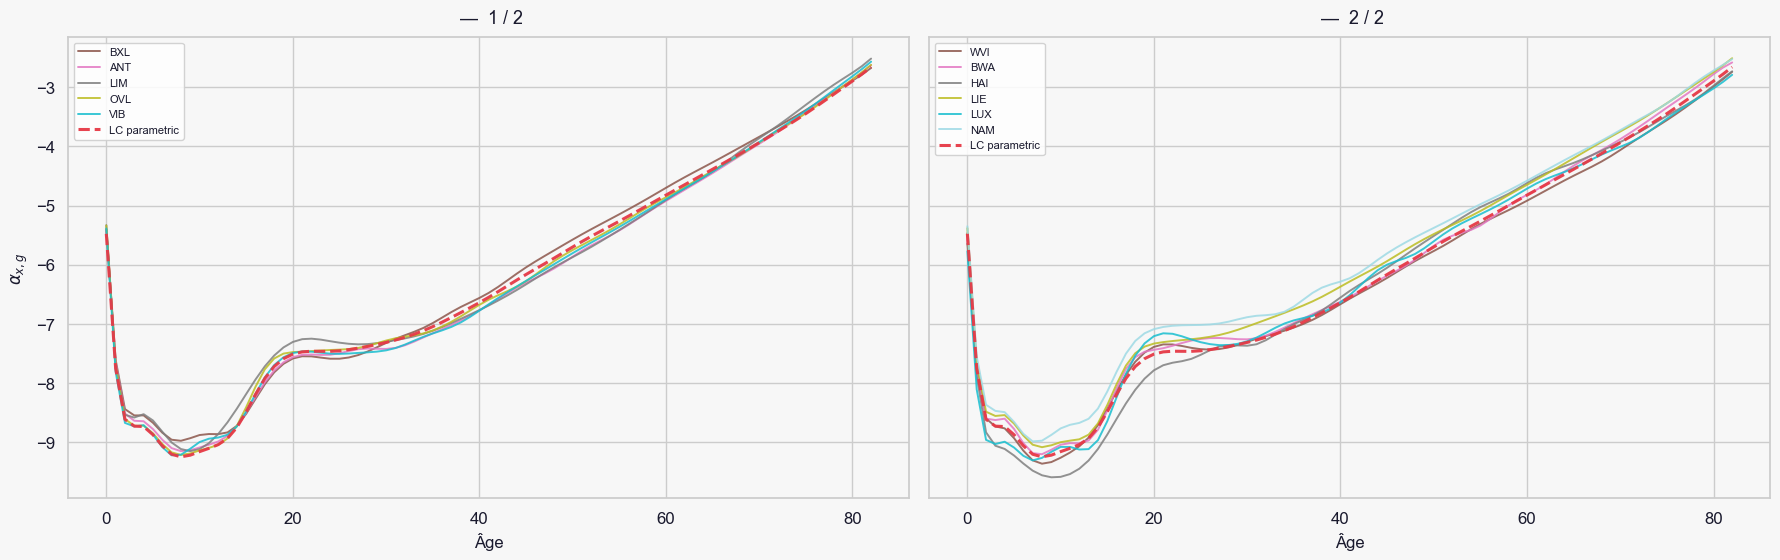

✅ Graphe sauvegardé : regional_curves.png


In [26]:

import matplotlib.cm as cm
from matplotlib.lines import Line2D

# ─────────────────────────────────────────────
# CONFIG — adapte ces valeurs à ton projet
# ─────────────────────────────────────────────
CURVE_KEY   = "beta_xg"          # clé dans result_llp["curves"]
COMPARE_KEY = None                # ex: "beta_xg" dans result_ref, ou None

STYLE = "whitegrid"               # "dark", "whitegrid", "white"

# ─────────────────────────────────────────────
  # ← remplace par ta vraie courbe

# ─────────────────────────────────────────────
# Fonction principale
# ─────────────────────────────────────────────
def plot_regional_curves(
    xv,
    curves,           # shape (n_ages, n_regions)
    region_labels,
    compare_curve=None,
    compare_label="Référence",
    curve_key=r"$\beta_{x,g}$",
    title_prefix="Courbes régionales",
    style="whitegrid",
):
    import seaborn as sns
    sns.set_theme(style=style, font_scale=1.1)

    n_regions = len(region_labels)
    mid = n_regions // 2
    splits = [
        (region_labels[:mid],  curves[:, :mid],  " 1 / 2"),
        (region_labels[mid:],  curves[:, mid:],  " 2 / 2"),
    ]

    # Palette continue sur tout le set de régions
    palette = cm.get_cmap("tab20", n_regions)
    colors  = [palette(i) for i in range(n_regions)]

    fig, axes = plt.subplots(
        1, 2,
        figsize=(18, 6),
        sharey=True,
        facecolor="#F7F7F7" if style != "dark" else "#1C1C2E",
    )
    fig.subplots_adjust(wspace=0.08)

    bg_color  = "#F7F7F7" if style != "dark" else "#1C1C2E"
    txt_color = "#1a1a2e"  if style != "dark" else "#E0E0E0"

    for ax, (labels, sub_curves, subtitle) in zip(axes, splits):
        ax.set_facecolor(bg_color)
        start_idx = 0 if labels is region_labels[:mid] else mid

        for j, region in enumerate(labels):
            global_idx = start_idx + j
            ax.plot(
                xv, sub_curves[:, j],
                color=colors[global_idx],
                linewidth=1.4,
                alpha=0.85,
                label=region,
            )

        # Courbe de référence
        if compare_curve is not None:
            ax.plot(
                xv, compare_curve,
                color="#E63946",
                linewidth=2.2,
                linestyle="--",
                alpha=0.95,
                label=compare_label,
                zorder=10,
            )

        ax.set_xlabel("Âge", color=txt_color, fontsize=12)
        ax.set_title(f"{title_prefix} — {subtitle}", color=txt_color, fontsize=13, pad=10)
        ax.tick_params(colors=txt_color)
        for spine in ax.spines.values():
            spine.set_edgecolor("#CCCCCC" if style != "dark" else "#444")

        legend = ax.legend(
            fontsize=8,
            framealpha=0.85,
            loc="upper left",
            ncol=1,
        )
        for text in legend.get_texts():
            text.set_color(txt_color)

    axes[0].set_ylabel(curve_key, color=txt_color, fontsize=12)

    # Titre global
    fig.suptitle(
        title_prefix,
        fontsize=16,
        fontweight="bold",
        color=txt_color,
        y=1.02,
    )

    # # Légende partagée pour la courbe de référence (si présente)
    # if compare_curve is not None:
    #     ref_handle = Line2D([0], [0], color="#E63946", linewidth=2.2, linestyle="--")
    #     fig.legend(
    #         handles=[ref_handle],
    #         labels=[compare_label],
    #         loc="lower center",
    #         ncol=1,
    #         fontsize=10,
    #         framealpha=0.9,
    #         bbox_to_anchor=(0.5, -0.06),
    #     )

    plt.tight_layout()
    #plt.savefig(path_fr + "/regional_alpha_LL_parametric.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Graphe sauvegardé : regional_curves.png")


# ─────────────────────────────────────────────
# Appel
# ─────────────────────────────────────────────
plot_regional_curves(
    xv            = xv,
    curves        = result_llp["curves"]["alpha_xg"],
    region_labels = region_labels,
    compare_curve = results_lcp_nat["curves"]["alpha_x"] , #results_lc_classic['parameters']["bx_coef"],
    compare_label = 'LC parametric',
    curve_key     = r"$\alpha_{x,g}$",
    title_prefix  = '',
    style         = STYLE,
)

##### Graphiques

In [27]:
mu_obs = Dxtg / Extg
mu_nat = results_lcp_nat["fitted_values"]["mu"]  # (83, 34)

mu_nat_rep = np.repeat(mu_nat[:, :, None], 22, axis=2)
curves = {
    "Observed": mu_obs,
    "LL": result_ll['fitted_values']['mu'],
    "LL parametric": result_llp["fitted_values"]["mu"],
    "LC parametric": mu_nat_rep }


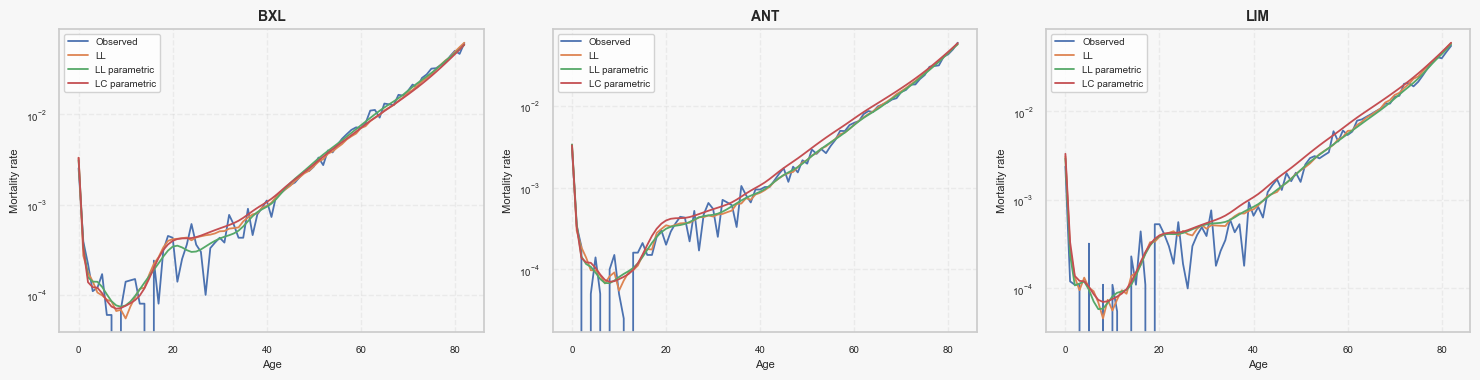

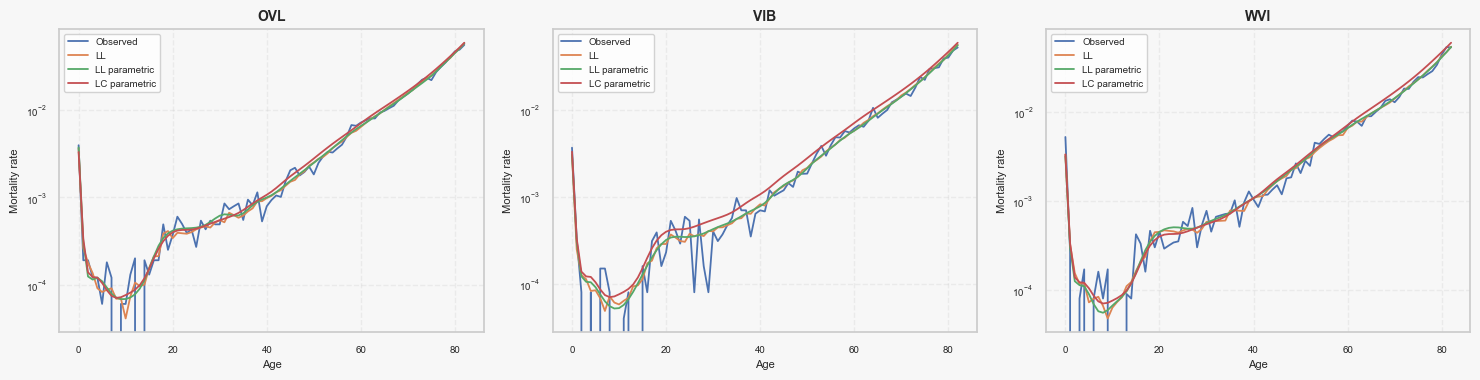

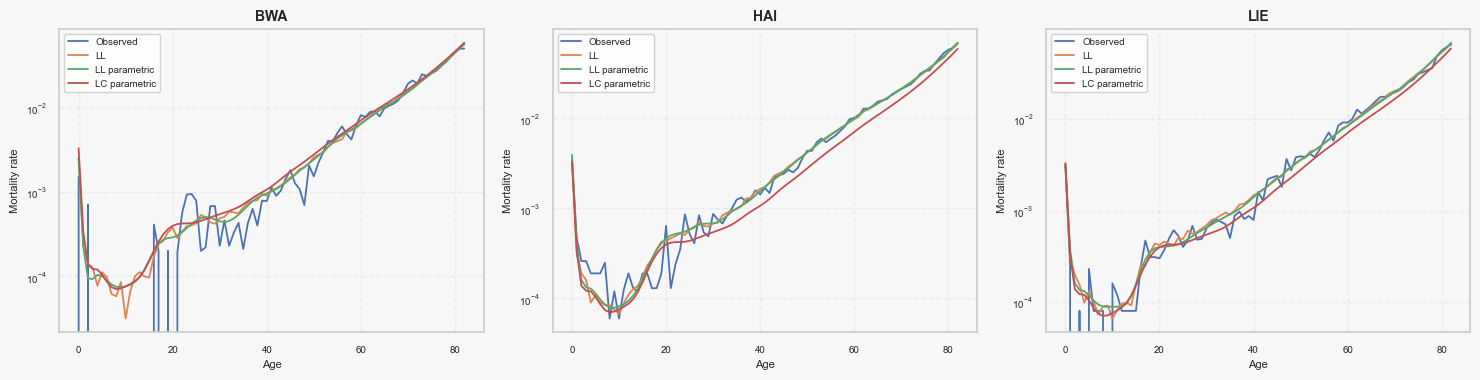

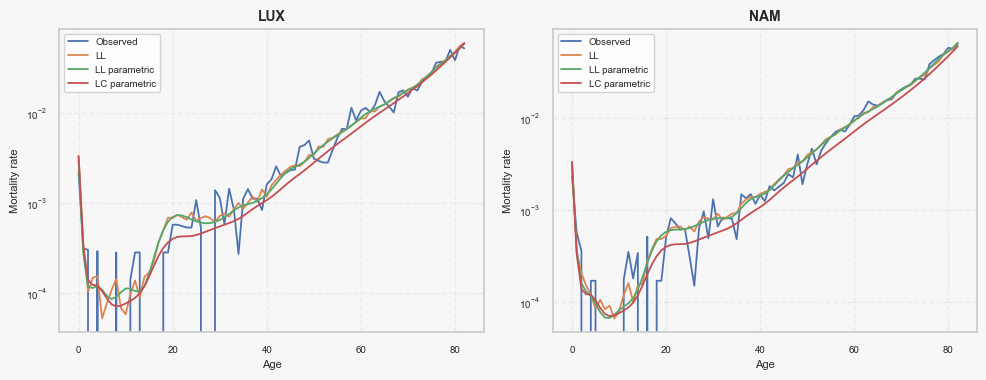

In [28]:
# ── RegionalCurvePlotter ────────────────────────────────────────────
plotter = RegionalCurvePlotter(
    x_values=xv,
    curves_dict=curves,
    tv=tv,
    regions=region_labels,
)
plotter.plot(year_to_plot=2015)
#plotter.save(path_fr+ "/mortality_v2_2015.png")

### Projector

###### Lee Carter and Lee and Li

In [29]:
n_sim = 2000
horizon = 50
covid_years = ['2019','2020',"2021"]

In [30]:
proj_lcp_stoch = ProjectorLC_SVD(
    results_lcp_nat, tv,
    horizon=horizon,
    model="rw",
    exclude_years=covid_years,
    stochastic=False,
    n_sim=n_sim,
    nb_components=2
    ).project()

###### Lee and Li parametric & classic

In [31]:
proj_llp_stoch = ProjectorLeeLi(
    result_llp, tv,
    horizon=horizon,
    model="rw",
    exclude_years=covid_years,
    stochastic=False,
    n_sim=n_sim,
    nb_components=2
).project()

In [32]:
proj_ll_stoch = ProjectorLeeLi(
    result_ll, tv,
    horizon=horizon,
    model="rw",
    exclude_years=covid_years,
    stochastic=False,
    n_sim=n_sim,
    nb_components=2
).project()

In [33]:
# kappa = result_llp["parameters"]["kappa"]
# kappa_g = result_llp["parameters"]["kappa_g"]  # (nb_regions, T)

# var_kappa = np.var(kappa)
# var_kappa_g = np.var(kappa_g)

# print("Var kappa (commun):", var_kappa)
# print("Var kappa_g (regional):", var_kappa_g)

###### kappa_g plot

In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# 3b. Plot kappa_g (historical + projected) by region
# ─────────────────────────────────────────────────────────────────────────────

def plot_kappa_g(
    kappa_g_hist: np.ndarray,
    tv: np.ndarray,
    projection: dict,
    horizon: int,
    stochastic: bool = True,
    region_names: list = None,
    exclude_years: list = None,
    regions_per_fig: int = 3,
    save_path: str = None,
    dpi: int = 150,
):
    """
    Plot historical and projected kappa_g by region.
    Generates one figure per group of `regions_per_fig` regions.

    Parameters
    ----------
    kappa_g_hist    : (nb_regions, nb_years)
        Historical kappa_g from the fitted model.
    tv              : array-like
        Observation year vector, length nb_years.
    projection      : dict
        Output of ProjectorLeeLi.project().
    horizon         : int
        Number of projected years.
    stochastic      : bool
        If True, uses median + confidence interval from projection dict.
    region_names    : list, optional
        Labels for each region. Defaults to ["Region 1", "Region 2", ...].
    exclude_years   : list, optional
        Years to mark as excluded (greyed out) on the plot.
    regions_per_fig : int
        Number of regions per figure (= number of subplot columns). Default: 3.
    save_path       : str | Path, optional
        Base path for saving figures. If provided, each figure is saved with
        a "_part{i}" suffix before the extension.
        Example: "output/kappa_g.png"  →  "output/kappa_g_part1.png", ...
        The parent directory is created automatically if it does not exist.
    dpi             : int
        Resolution used when saving (default: 150).

    Returns
    -------
    figs : list of matplotlib Figure
        One figure per group of regions.
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    from pathlib import Path

    tv            = np.asarray(tv)
    nb_regions    = kappa_g_hist.shape[0]
    tv_proj       = np.arange(tv[-1] + 1, tv[-1] + 1 + horizon)
    exclude_years = exclude_years if exclude_years is not None else []

    if region_names is None:
        region_names = [f"Region {g+1}" for g in range(nb_regions)]

    colors  = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    n_figs  = int(np.ceil(nb_regions / regions_per_fig))
    figs    = []

    for f in range(n_figs):
        g_start = f * regions_per_fig
        g_end   = min(g_start + regions_per_fig, nb_regions)
        group   = list(range(g_start, g_end))
        ncols   = len(group)

        fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 3.5), sharey=False)
        axes = np.array(axes).reshape(-1)

        for pos, g in enumerate(group):
            ax    = axes[pos]
            color = colors[g % len(colors)]
            hist  = kappa_g_hist[g, :]

            # ── historical ──────────────────────────────────────────
            mask_excl = np.isin(tv, exclude_years)
            ax.plot(tv[~mask_excl], hist[~mask_excl], color=color, lw=1.8, label="")
            if mask_excl.any():
                ax.plot(tv[mask_excl], hist[mask_excl], color=color, lw=1.2,
                        linestyle="--", alpha=0.45, label="Années exclues")

            # ── projection ──────────────────────────────────────────
            last_val = hist[-1]

            if stochastic:
                kg_med   = projection["kappa_g_median"]
                kg_lo    = projection["kappa_g_lower"]
                kg_hi    = projection["kappa_g_upper"]

                tv_bridge  = np.concatenate([[tv[-1]],  tv_proj])
                med_bridge = np.concatenate([[last_val], kg_med[:, g]])
                lo_bridge  = np.concatenate([[last_val], kg_lo[:, g]])
                hi_bridge  = np.concatenate([[last_val], kg_hi[:, g]])

                ax.fill_between(tv_bridge, lo_bridge, hi_bridge,
                                color=color, alpha=0.18, label="IC 95%")
                ax.plot(tv_bridge, med_bridge, color=color, lw=1.8,
                        linestyle="--", label="Médiane projetée")
            else:
                kg_fut     = projection["kappa_g_future"]
                tv_bridge  = np.concatenate([[tv[-1]],  tv_proj])
                fut_bridge = np.concatenate([[last_val], kg_fut[:, g]])
                ax.plot(tv_bridge, fut_bridge, color=color, lw=1.8,
                        linestyle="--", label="Projected")

            # ── styling ─────────────────────────────────────────────
            ax.axvline(tv[-1], color="grey", lw=0.8, linestyle=":")
            ax.set_title(region_names[g], fontsize=11)
            ax.set_xlabel("Année")
            ax.set_ylabel(r"$\kappa_t^{(g)}$")
            ax.legend(fontsize=7, loc="best")
            ax.grid(True, alpha=0.3)

        fig.tight_layout()
        figs.append(fig)

        # ── save ────────────────────────────────────────────────────
        # if save_path is not None:
        #     p   = Path(save_path)
        #     p.parent.mkdir(parents=True, exist_ok=True)
        #     out = p.parent / f"{p.stem}_part{f + 1}{p.suffix}"
        #     fig.savefig(out, dpi=dpi, bbox_inches="tight")
        #     print(f"✅ Saved → {out}")

    plt.show()
    return figs

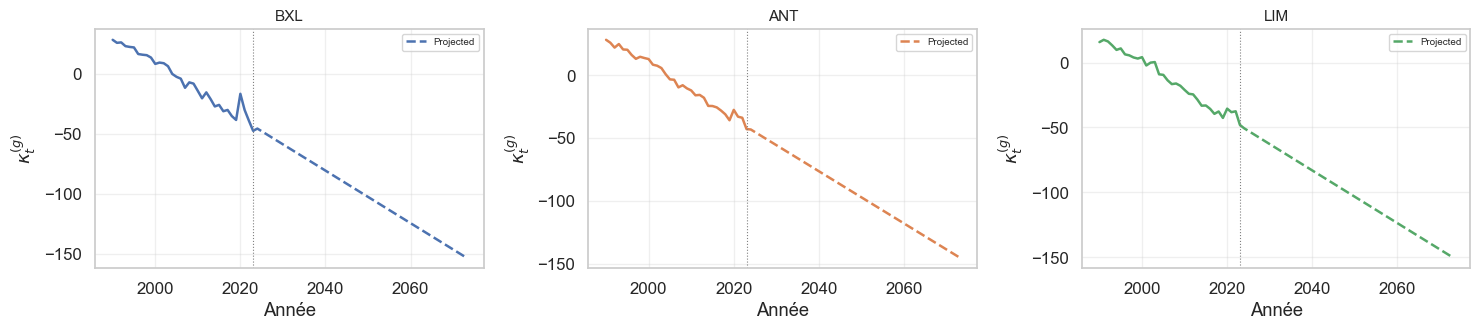

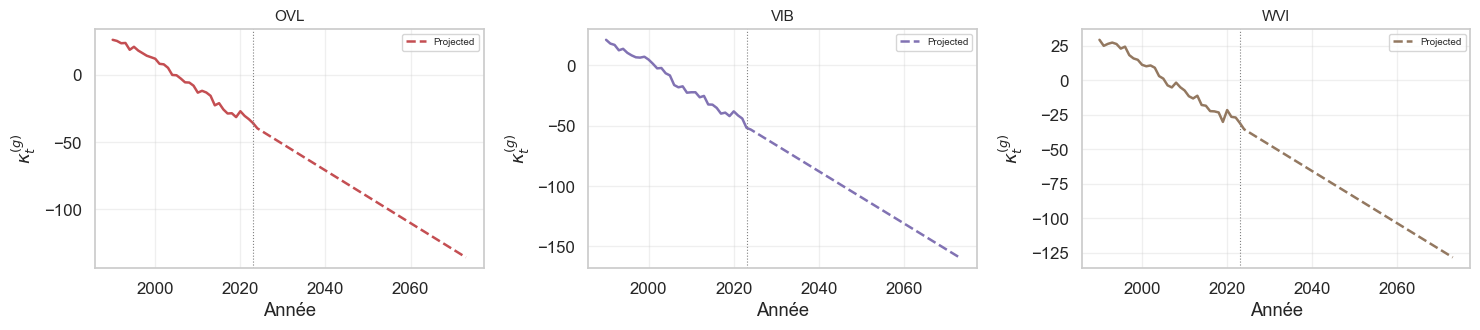

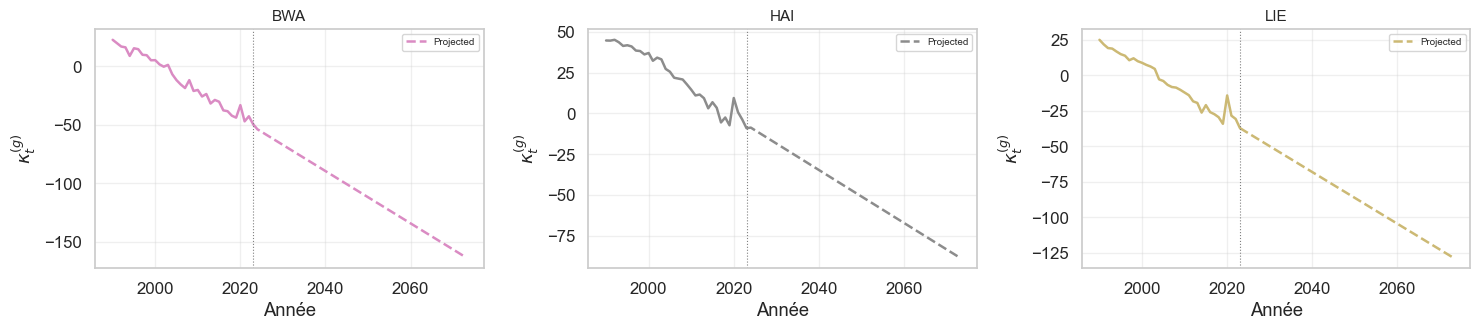

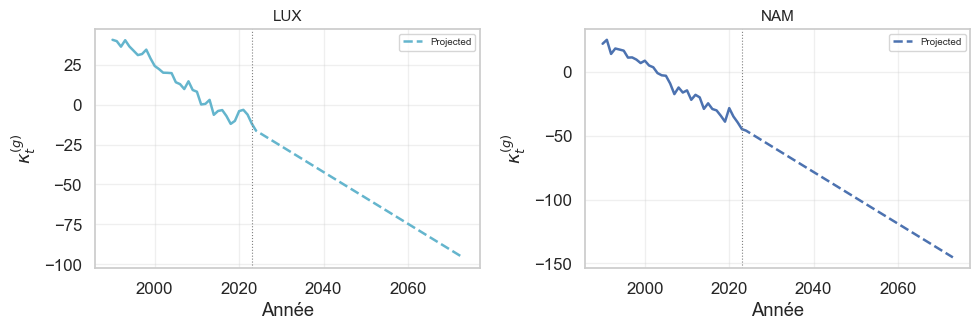

In [35]:
fig = plot_kappa_g(
    kappa_g_hist=result_llp["parameters"]["kappa_g"],  # (nb_regions, T)
    tv=tv,
    projection=proj_llp_stoch,          # dict retourné par .project()
    horizon=50,
    stochastic=False,         # False si projection déterministe
    region_names=region_labels,
    exclude_years=[],   #2019,2020,2021
    save_path=path_fr + "/kappa_by_region_project.png"
    )


##### HighAgeExtrapolator

In [36]:
start_age = 60

In [37]:
# logmu_nation_lcp, xv_full = HighAgeExtrapolator(
#     xv          = xv,
#     x_extrap    = 110,          # âge cible
#     x_extrap_start = start_age,        # début de la fenêtre de régression commencer à 60 ans 
#     method="linear",
#     log_Muxtg   = logmu_lc_national, auto_start =False).extrapolate()
    

# # logmu_extrap
# # xv_full      → [0, 1, ..., 110]

# print("log-mu extrapolé :", logmu_nation_lcp.shape)   
# print("Grille d'âges    :", xv_full[[0, -1]]) 

In [38]:
# ── 2. Extrapolation 82 → 110 ─────────────────────────────────────
logmu_extrap_llp, xv_full = HighAgeExtrapolator(
    xv          = xv,
    x_extrap    = 110,          # âge cible
    x_extrap_start = start_age,        # début de la fenêtre de régression commencer à 60 ans 
    method="linear",
    log_Muxtg   = proj_llp_stoch["logmu_future"], auto_start =False).extrapolate()
    

# logmu_extrap
# xv_full      → [0, 1, ..., 110]

print("log-mu extrapolé :", logmu_extrap_llp.shape)   
print("Grille d'âges    :", xv_full[[0, -1]])  

log-mu extrapolé : (111, 50, 11)
Grille d'âges    : [  0 110]


In [39]:
# ── 2. Extrapolation 82 → 110 ─────────────────────────────────────
logmu_extrap_ll, xv_full = HighAgeExtrapolator(
                    xv          = xv,
                    x_extrap    = 110,          # âge cible
                    x_extrap_start = start_age,        # début de la fenêtre de régression
                    method="linear",
                    log_Muxtg   = proj_ll_stoch["logmu_future"],auto_start =False
                ).extrapolate()
# logmu_extrap
# xv_full      → [0, 1, ..., 110]

print("log-mu extrapolé :", logmu_extrap_ll.shape)   
print("Grille d'âges    :", xv_full[[0, -1]])      

log-mu extrapolé : (111, 50, 11)
Grille d'âges    : [  0 110]


In [40]:
# ── 2. Extrapolation 82 → 110 ## Lee carter paramétrique
logmu_llp_hist, xv_full = HighAgeExtrapolator(
    xv          = xv,
    x_extrap    = 110,          # âge cible
    x_extrap_start = start_age,        # début de la fenêtre de régression
    method="linear",
    log_Muxtg   = result_llp["fitted_values"]["log_mu"],auto_start =False
).extrapolate()
# logmu_extrap 
# xv_full      → [0, 1, ..., 110]

print("log-mu extrapolé :", logmu_llp_hist.shape)  
print("Grille d'âges    :", xv_full[[0, -1]])      # [  0 110]

log-mu extrapolé : (111, 34, 11)
Grille d'âges    : [  0 110]


In [41]:
# ── 2. Extrapolation 82 → 110 ## Lee carter paramétrique
logmu_ll_hist, xv_full = HighAgeExtrapolator(
    xv          = xv,
    x_extrap    = 110,          # âge cible
    x_extrap_start = start_age,        # début de la fenêtre de régression
    method="linear",
    log_Muxtg   = result_ll["fitted_values"]["log_mu"],auto_start =False
).extrapolate()
# logmu_extrap 
# xv_full      → [0, 1, ..., 110]

print("log-mu extrapolé :", logmu_ll_hist.shape)  
print("Grille d'âges    :", xv_full[[0, -1]])      # [  0 110]

log-mu extrapolé : (111, 34, 11)
Grille d'âges    : [  0 110]


In [42]:
logmu_full_llp = concat_logmu_time(logmu_llp_hist,logmu_extrap_llp)
logmu_full_ll = concat_logmu_time(logmu_ll_hist,logmu_extrap_ll)

In [43]:
print(logmu_full_llp.shape)
print(logmu_full_ll.shape)

(111, 84, 11)
(111, 84, 11)


#### LifeExpectancy

In [44]:
esp_llp = LifeExpectancy(np.exp(logmu_full_llp)).compute()
esp_ll = LifeExpectancy(np.exp(logmu_full_ll)).compute()

In [45]:
esp_llp.shape

(111, 84, 11)

In [46]:
e0_llp = esp_llp[0, :, :]  
e0_ll = esp_ll[0, :, :] 
# shape = (nb_horizon, nb_region)

In [47]:

df_esp_llp = pd.DataFrame(
    e0_llp,
    index=np.arange(1990, 2023 + 51),   # ex: [2023, 2030, 2050]
    columns=region_labels   # ex: ["Ile-de-France", "Occitanie", ...]
)

df_esp_llp.index.name = "horizon"
#df_esp_llp.to_csv(path_fr + "/LifeExpectancy_at_birth_ll_parametric.csv", index=False)

In [48]:

df_esp_ll = pd.DataFrame(
    e0_ll,
    index=np.arange(1990, 2023 + 51),   # ex: [2023, 2030, 2050]
    columns=region_labels   # ex: ["Ile-de-France", "Occitanie", ...]
)

df_esp_ll.index.name = "horizon"
#df_esp_ll.to_csv(path_fr + "/LifeExpectancy_at_birth_ll.csv", index=False)

In [52]:
df_esp_ll

,BXL,ANT,LIM,OVL,VlB,WVl,BWA,HAI,LIE,LUX,NAM
horizon,,,,,,,,,,,
1990,75.608374,76.072014,76.331329,75.778509,76.539760,76.042749,76.070062,74.188808,74.371956,74.786732,74.251503
1991,75.835528,76.304287,76.654883,75.914641,76.843780,76.511435,75.846331,74.234007,74.673472,74.572878,73.730911
1992,76.038863,76.608457,76.541952,76.033780,76.844466,76.491645,76.567308,74.169777,75.019220,75.465895,74.928598
1993,76.025487,76.578451,76.790778,76.066105,77.411548,76.387612,76.440402,74.375864,75.001378,74.806321,74.299172
1994,76.519267,76.978408,77.183667,76.679773,77.405617,76.714144,77.273459,74.674574,75.463341,75.230456,74.686632
...,...,...,...,...,...,...,...,...,...,...,...
2069,89.753646,91.874914,91.418294,91.710152,92.418383,92.788069,92.967891,88.327041,88.487387,90.778707,89.956253
2070,89.919039,92.056454,91.588991,91.896460,92.599991,92.990458,93.169749,88.521791,88.666424,90.985333,90.158637
2071,90.084224,92.237639,91.759319,92.082431,92.781187,93.192400,93.371171,88.716748,88.845598,91.191774,90.360977


In [49]:
#df_esp_llp.head(70)

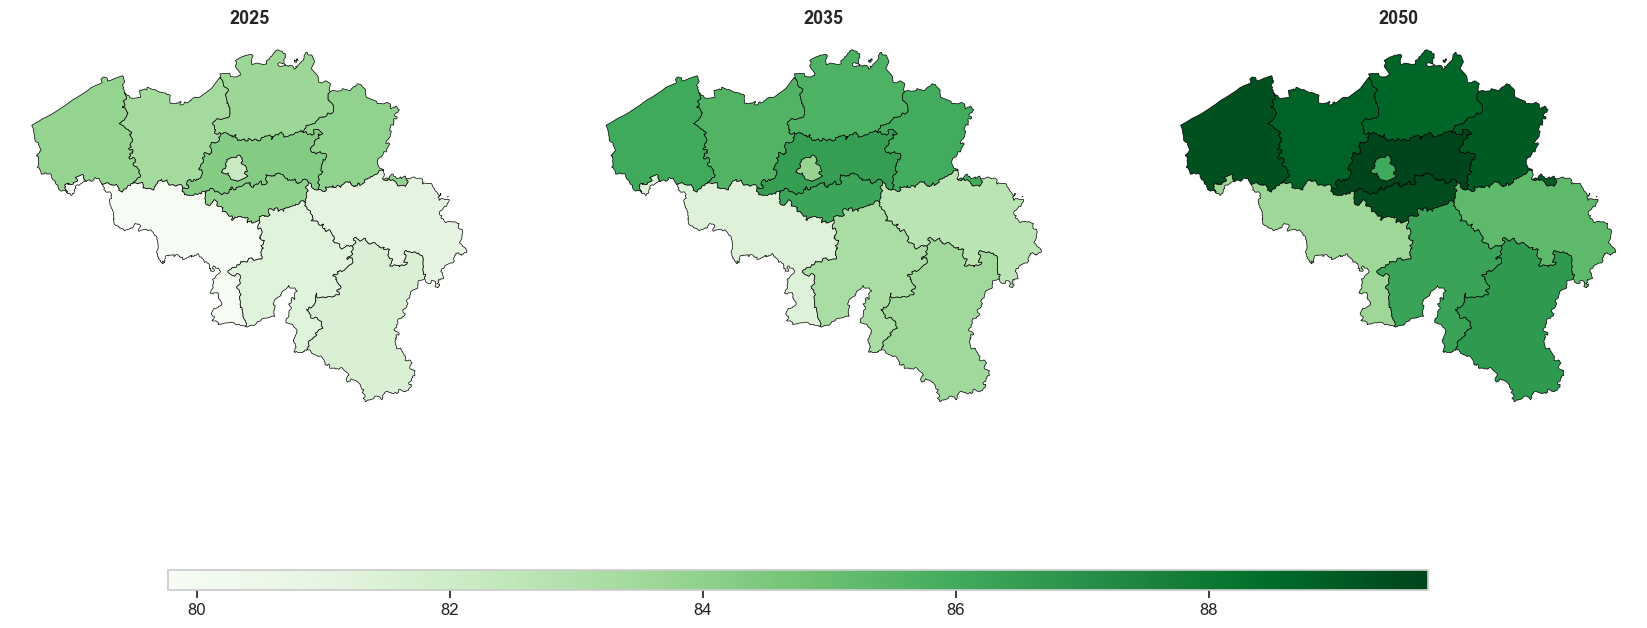

✅ Saved → C:/Users/Idrissa Belem/Documents/GitHub/morta_nuts2/output_note/BE/LifeExpectancy_at_birth_ll_parametric_color_Detra.png


In [50]:
#Paramètre
tv_future = np.arange(1990, 2023 + 28) #années
mp = MapPlotter(regions, esp_llp, tv_future, "BE", "",cmap="Greens")
#mp.plot_single_year(year=2030)
mp.plot_compare_years(years=[2025, 2035,2050])
mp.save(path_fr + "/LifeExpectancy_at_birth_ll_parametric_color_Detra.png")

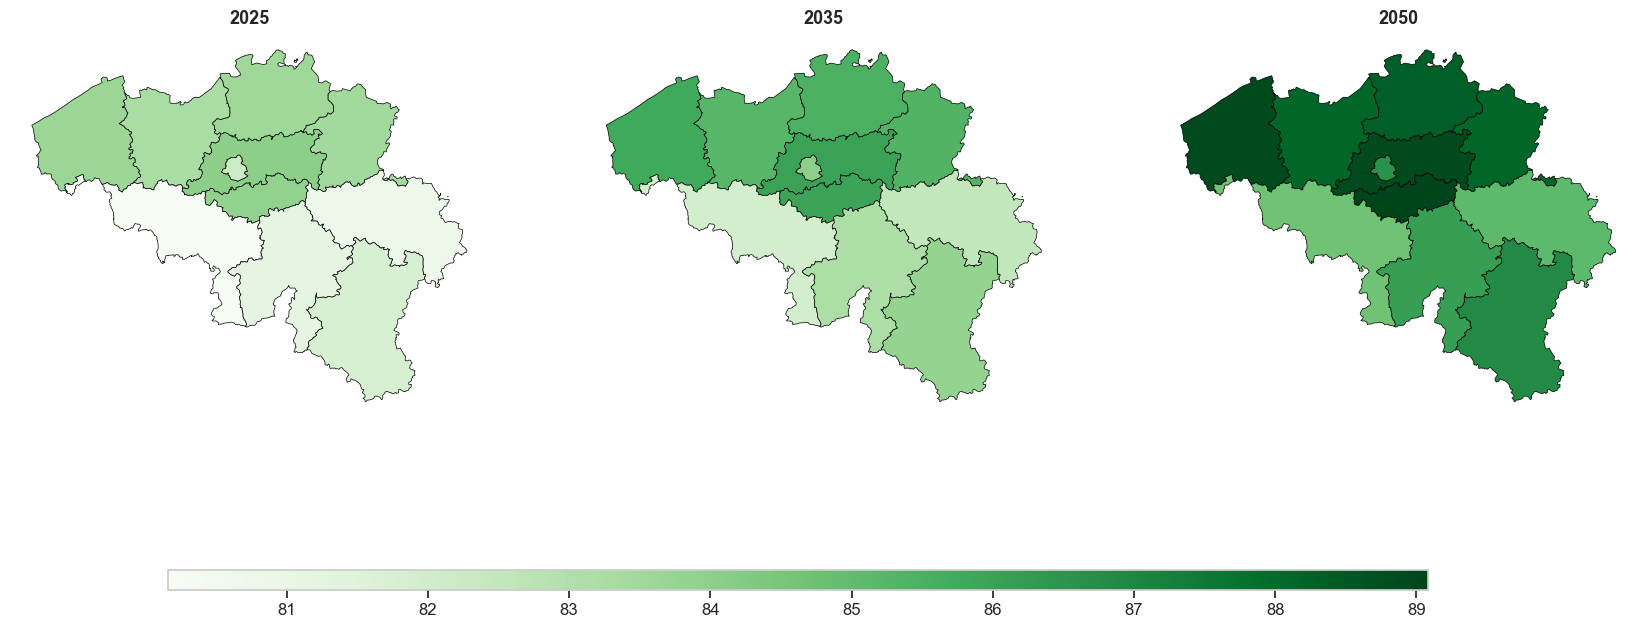

✅ Saved → C:/Users/Idrissa Belem/Documents/GitHub/morta_nuts2/output_note/BE/LifeExpectancy_at_birth_ll_color_Detra.png


In [51]:
mp = MapPlotter(regions, esp_ll, tv_future, "BE", "", cmap = "Greens")
#mp.plot_single_year(year=2030)
mp.plot_compare_years(years=[2025, 2035,2050])
mp.save(path_fr + "/LifeExpectancy_at_birth_ll_color_Detra.png")

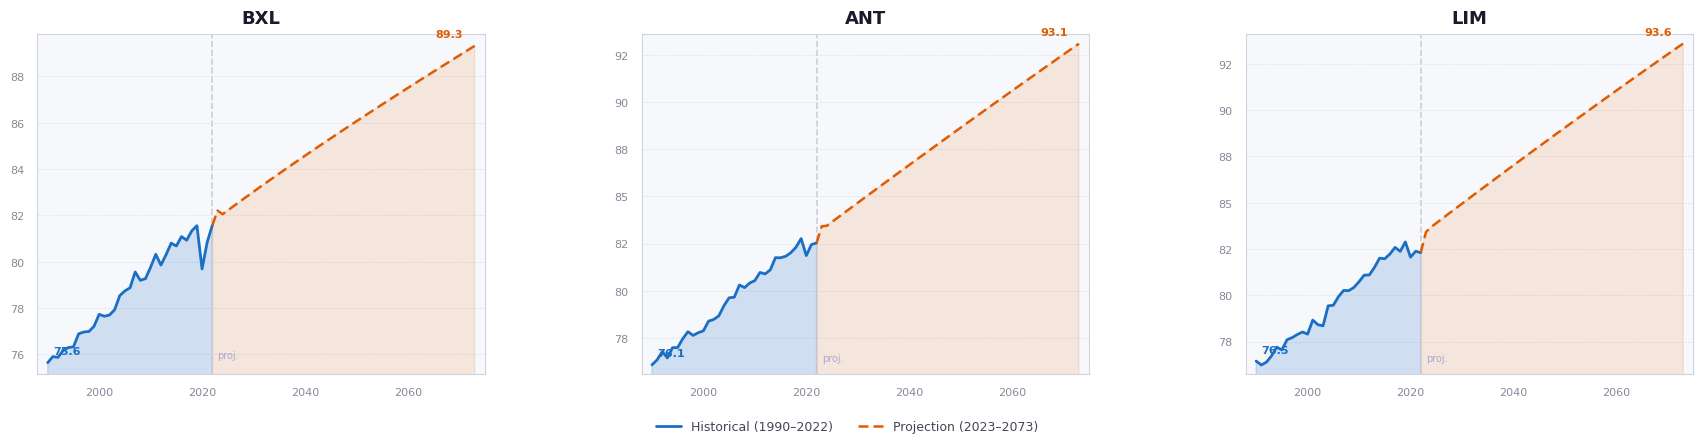

✓ Figure 1/4 sauvegardée : esperance_vie_fig01.png


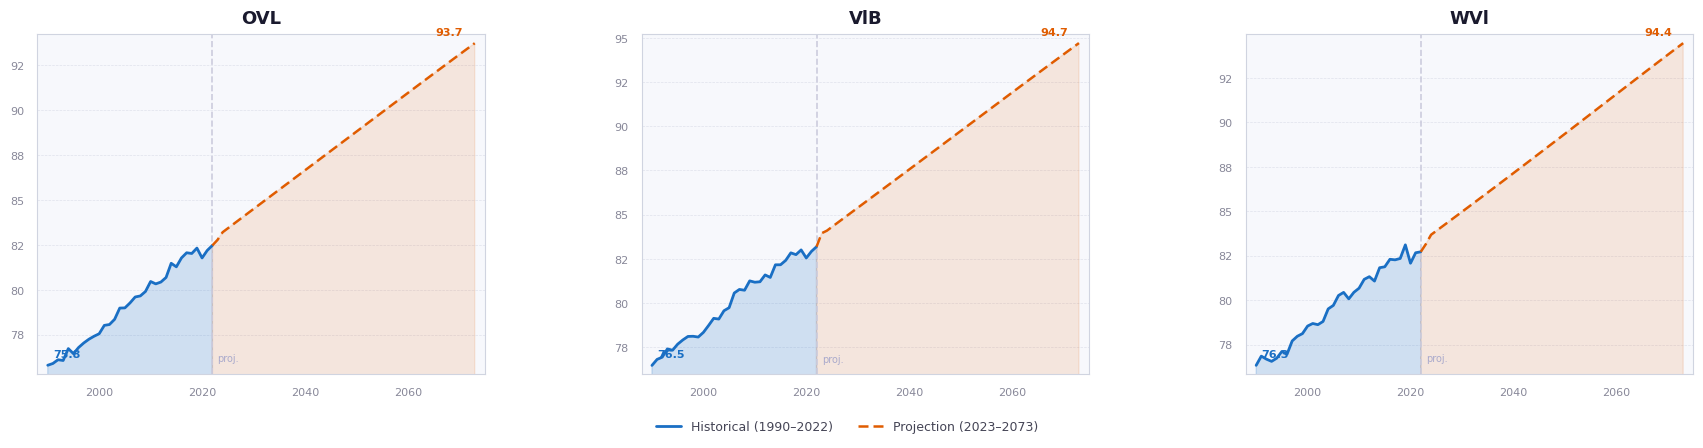

✓ Figure 2/4 sauvegardée : esperance_vie_fig02.png


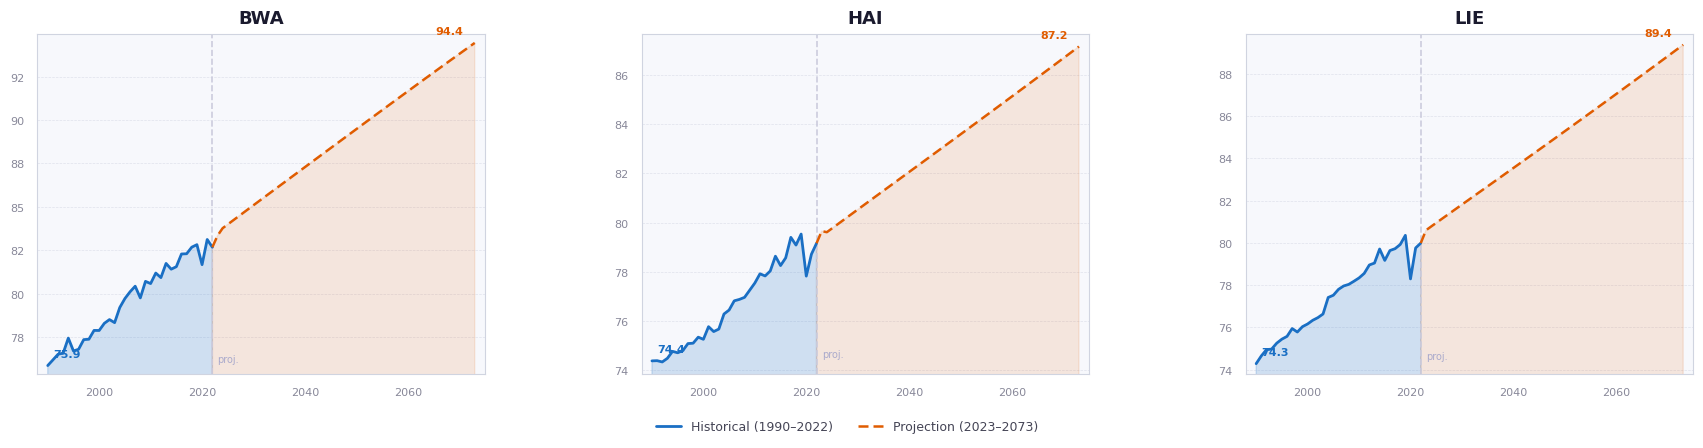

✓ Figure 3/4 sauvegardée : esperance_vie_fig03.png


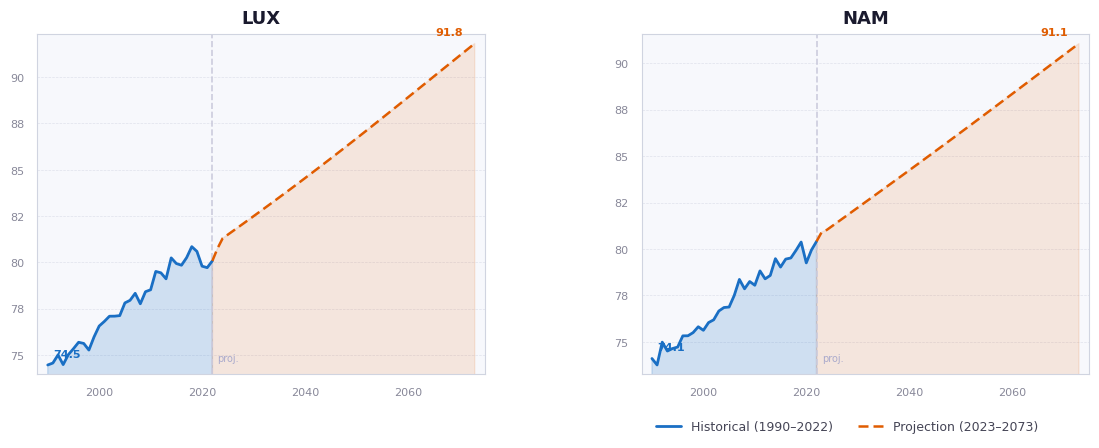

✓ Figure 4/4 sauvegardée : esperance_vie_fig04.png


In [63]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D

# ── Palette & style ───────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor":  "#ffffff",
    "axes.facecolor":    "#f7f8fc",
    "axes.edgecolor":    "#d0d4e0",
    "axes.labelcolor":   "#444455",
    "xtick.color":       "#888899",
    "ytick.color":       "#888899",
    "grid.color":        "#e0e2ec",
    "grid.linewidth":    0.6,
    "text.color":        "#1a1a2e",
    "font.family":       "DejaVu Sans",
})

# ── Paramètres ────────────────────────────────────────────────────────────────
HIST_LAST_YEAR = 2022   # coupure historique / projection
ACCENT = "#1a6fc4"      # bleu historique (plus foncé sur fond blanc)
PROJ   = "#e05c00"      # orange projection (plus foncé sur fond blanc)

# ── df_llp : index.name = "horizon", colonnes = régions ──────────────────────
# df_llp doit déjà être chargé dans l'environnement
# Exemple de structure :
#         BXL        ANT        LIM  ...
# horizon
# 1990    75.608374  76.072014  76.331329  ...
# 1991    75.835528  76.304287  76.654883  ...
# ...
# 2073    90.413962  92.598911  92.098857  ...

regions = df_esp_llp.columns.tolist()
years   = df_esp_llp.index.to_numpy()

# ── Groupes de 3 régions par figure ──────────────────────────────────────────
NCOLS     = 3
group_size = NCOLS  # 3 régions par figure

legend_elements = [
    Line2D([0], [0], color=ACCENT, linewidth=2,            label="Historical (1990–2022)"),
    Line2D([0], [0], color=PROJ,   linewidth=1.8,
           linestyle=(0, (4, 2)),                           label="Projection (2023–2073)"),
]

# Découpe des régions en groupes de 3
groups = [regions[i:i+group_size] for i in range(0, len(regions), group_size)]

for fig_idx, group in enumerate(groups):
    n = len(group)  # 1, 2 ou 3 selon le dernier groupe
    fig, axes = plt.subplots(1, NCOLS, figsize=(18, 5), squeeze=False)
    axes = axes.flatten()

    fig.subplots_adjust(hspace=0.4, wspace=0.35, top=0.83, bottom=0.15, left=0.05, right=0.97)

    fig.text(0.5, 0.95, "",
             ha="center", fontsize=14, fontweight="bold", color="#1a1a2e")
    fig.text(0.5, 0.89, "",
             ha="center", fontsize=9, color="#666677")

    for ax, region in zip(axes, group):
        vals_all = df_esp_llp[region].to_numpy()

        mask_h = years <= HIST_LAST_YEAR
        mask_p = years >= HIST_LAST_YEAR

        yh, vh = years[mask_h], vals_all[mask_h]
        yp, vp = years[mask_p], vals_all[mask_p]

        # Zones colorées
        ax.fill_between(yh, vh, alpha=0.18, color=ACCENT)
        ax.fill_between(yp, vp, alpha=0.12, color=PROJ)

        # Ligne de coupure
        ax.axvline(HIST_LAST_YEAR, color="#ccccdd", linewidth=1.2, linestyle="--", zorder=1)
        ax.text(HIST_LAST_YEAR + 1, vh.min() + 0.1, "proj.",
                fontsize=7, color="#aaaacc", va="bottom")

        # Courbes
        ax.plot(yh, vh, color=ACCENT, linewidth=2.0, solid_capstyle="round", zorder=3)
        ax.plot(yp, vp, color=PROJ,   linewidth=1.8, linestyle=(0, (4, 2)),
                solid_capstyle="round", zorder=3)

        # Annotations
        ax.annotate(f"{vh[0]:.1f}", xy=(yh[0], vh[0]), xytext=(4, 6),
                    textcoords="offset points", fontsize=8, color=ACCENT, fontweight="bold")
        ax.annotate(f"{vp[-1]:.1f}", xy=(yp[-1], vp[-1]), xytext=(-28, 6),
                    textcoords="offset points", fontsize=8, color=PROJ, fontweight="bold")

        # Titre
        ax.set_title(region, fontsize=13, fontweight="bold", color="#1a1a2e", pad=8)

        # Axes
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.0f"))
        ax.xaxis.set_major_locator(ticker.MultipleLocator(20))
        ax.tick_params(labelsize=8)
        ax.grid(True, axis="y", linestyle="--", linewidth=0.5)
        ax.grid(False, axis="x")
        ax.set_xlim(years.min() - 2, years.max() + 2)
        ax.set_ylim(vals_all.min() - 0.5, vals_all.max() + 0.5)

        for spine in ax.spines.values():
            spine.set_edgecolor("#d0d4e0")
            spine.set_linewidth(0.8)

    # Masquer les subplots vides du dernier groupe
    for ax in axes[n:]:
        ax.set_visible(False)

    # Légende
    fig.legend(handles=legend_elements, loc="lower center", ncol=2,
               fontsize=9, frameon=False, labelcolor="#444455",
               bbox_to_anchor=(0.5, 0.01))

    fname = f"esperance_vie_fig{fig_idx+1:02d}.png"
    plt.savefig(path_fr + fname, dpi=160, bbox_inches="tight", facecolor="#ffffff")
    plt.show()
    print(f"✓ Figure {fig_idx+1}/{len(groups)} sauvegardée : {fname}")

In [56]:
print(esp_llp.shape)
print(type(esp_llp))

(111, 84, 11)
<class 'numpy.ndarray'>


#### Annuity_pricing

In [395]:
# xe = np.array([60])  # âge de souscription

# price_national = Annuity_pricing(
#     xe       = xe,
#     xv       = xv,
#     log_Muxtg = logmu_nation_lcp,  # (nb_ages, horizon, nb_reg, nb_simul)
#     duration  = 20,
#     rate      = 0.02   # taux d'actualisation à adapter
# )

# print("price shape:", price_national.shape)  # (1, nb_reg, nb_simul)

In [396]:
# price_multi = Annuity_pricing(
#     xe       = xe,
#     xv       = xv,
#     log_Muxtg = logmu_extrap_lcp,  # (nb_ages, horizon, nb_reg, nb_simul)
#     duration  = 20,
#     rate      = 0.02   # taux d'actualisation à adapter
# )

# print("price shape:", price_multi.shape)  # (1, nb_reg, nb_simul)

In [397]:
# France_nuts2 = {
#     "FR10": "IDF",        # Île-de-France
#     "FRB0": "CVL",        # Centre-Val de Loire
#     "FRC1": "BOU",        # Bourgogne
#     "FRC2": "FCO",        # Franche-Comté
#     "FRD1": "BN",         # Basse-Normandie
#     "FRD2": "HN",         # Haute-Normandie
#     "FRE1": "NPC",        # Nord-Pas de Calais
#     "FRE2": "PIC",        # Picardie
#     "FRF1": "ALS",        # Alsace
#     "FRF2": "CHA",        # Champagne-Ardenne
#     "FRF3": "LOR",        # Lorraine
#     "FRG0": "PDL",        # Pays de la Loire
#     "FRH0": "BRE",        # Bretagne
#     "FRI1": "AQU",        # Aquitaine
#     "FRI2": "LIM",        # Limousin
#     "FRI3": "POI",        # Poitou-Charentes
#     "FRJ1": "LR",         # Languedoc-Roussillon
#     "FRJ2": "MPY",        # Midi-Pyrénées
#     "FRK1": "AUV",        # Auvergne
#     "FRK2": "RA",         # Rhône-Alpes
#     "FRL0": "PACA",       # Provence-Alpes-Côte d’Azur
#     "FRM0": "COR"         # Corse
# }


# region_labels = [France_nuts2.get(r, r) for r in regions]

In [398]:
# # Cas 1 – régions seules
# AnnuityBoxPlotter(price_multi, region_labels).plot()

  

In [ ]:
# # ── AnnuityBoxPlotter — one extra series ───────────────────────────
# AnnuityBoxPlotter(price_multi, region_labels, extra_series=[
#     ExtraSeries(price_national, "LC", position="last"),
# ]).plot()


: 

In [ ]:
# lcp_mean = np.mean(esp_lcp,axis=3)
# llp_mean = np.mean(esp_llp,axis=3)

: 

### Annexes

In [62]:
# shapef = gpd.read_file("C:/Users/Idrissa Belem/Documents/GitHub/test_projet/NUTS_files/NUTS_RG_01M_2024_3035.shp")
# stock = "C:/Users/Idrissa Belem/Documents/GitHub/morta_nuts2/data"
# mxt_raw = load_mxt_raw(shapef,country="FR",data_path=stock)
# Dxt_raw = load_dxt_raw(shapef,country="FR",data_path=stock)
# Lxt_raw = load_lxt_raw(shapef,country="FR",data_path=stock)

In [64]:

# #Construction base spline pour connaître n_basis
# B, knots, n_basis = make_bspline_basis(xv, degree, n_knots)

# ax_coef_init = np.zeros(n_basis)
# bx_coef_init = np.ones((len(regions), n_basis))
# kappa_init =  np.ones(len(tv))

# model_multi = LiLee.Parametric.LeeAndLi(
#     degree=degree,
#     n_knots=n_knots,
#     lam=lam,
#     nb_iter=5000,
#     eta0=0.2,
#     tol=1e-3,
#     verbose=True,
# )

# result_llp = model_multi.fit(
#     ax_coef_init  = ax_coef_init,
#     bx_coef_init  = bx_coef_init,
#     kappa_init    = kappa_init,
#     Extg          = Extg,
#     Dxtg          = Dxtg,
#     xv            = xv,
#     tv            = tv,)

In [ ]:
# # Juste après init_params, avant le fit
# alpha_coef, beta_coef, beta_g_coef, kappa_common, kappa_g = model_p.init_params(Dxtg, Extg, xv)

# print("kappa_g NaN :", np.isnan(kappa_g).any())
# print("beta_g_coef NaN :", np.isnan(beta_g_coef).any())
# print("kappa_common NaN :", np.isnan(kappa_common).any())

# # Drifts kappa_g après init
# diffs = np.diff(kappa_g, axis=1)
# drift = diffs.mean(axis=1)
# for g, name in enumerate(regions):
#     print(f"{name}: drift = {drift[g]:.4f}")

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# mae_regional = {
#     "Li and Lee variant": mae_ll['wmae_by_region'],  # (nb_regions,)
#     "Li and Lee":         mae_llp['wmae_by_region'],          # (nb_regions,)
# }

# mae_national = {
#     "National model": mae_lcp['wmae_global'],  # scalaire
# }

# France_nuts2 = {
#     "FR10": "IDF", "FRB0": "CVL", "FRC1": "BOU", "FRC2": "FCO",
#     "FRD1": "BN",  "FRD2": "HN",  "FRE1": "NPC", "FRE2": "PIC",
#     "FRF1": "ALS", "FRF2": "CHA", "FRF3": "LOR", "FRG0": "PDL",
#     "FRH0": "BRE", "FRI1": "AQU", "FRI2": "LIM", "FRI3": "POI",
#     "FRJ1": "LR",  "FRJ2": "MPY", "FRK1": "AUV", "FRK2": "RA",
#     "FRL0": "PACA","FRM0": "COR"
# }
# region_labels = list(France_nuts2.values())

# all_models  = list(mae_regional.keys()) + list(mae_national.keys())
# n_models    = len(all_models)
# colors      = ["#1f77b4", "#ff7f0e", "#2ca02c"]
# width       = 0.8 / n_models
# n           = len(region_labels)
# x           = np.arange(n + 1)  # +1 pour la colonne nationale

# fig, ax = plt.subplots(figsize=(15, 5))

# # --- Barres régionales ---
# for i, (model, color) in enumerate(zip(mae_regional.keys(), colors)):
#     offset = (i - n_models / 2 + 0.5) * width
#     ax.bar(x[:n] + offset, mae_regional[model], width, label=model, color=color)

# # --- Barre nationale (même width, même style) ---
# for i, (model, value) in enumerate(mae_national.items()):
#     model_idx = len(mae_regional) + i
#     offset = (model_idx - n_models / 2 + 0.5) * width
#     ax.bar(x[-1] + offset, value, width, label=f"{model}", color=colors[model_idx])

# # Ligne verticale de séparation
# ax.axvline(n - 0.5, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)

# xtick_labels = region_labels + ["National"]
# ax.set_xticks(x)
# ax.set_xticklabels(xtick_labels, rotation=0, fontsize=8)
# ax.set_xlabel("Région")
# ax.set_ylabel("WMAE")
# ax.legend()
# ax.grid(axis="y", alpha=0.3)

# plt.tight_layout()
# plt.show()